# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [18]:
#Build a SINGLE-LABEL dataset from MIMIC-IV:
#One discharge summary (DS) note per admission (hadm_id)
#merged with the PRIMARY diagnosis only (seq_num == 1)
#with human-readable ICD description (long_title).


import os
import pandas as pd

# -----------------------------
# Config / Paths
# -----------------------------
DISCHARGE_PATH = "data/note/discharge.csv.gz"          # DS notes
DIAG_PATH      = "data/hosp/diagnoses_icd.csv.gz"      # diagnoses (has seq_num)
ICD_LU_PATH    = "data/hosp/d_icd_diagnoses.csv.gz"    # ICD descriptions
OUT_DIR        = "data/processed"
OUT_PATH       = os.path.join(OUT_DIR, "merged_single_label_minimal.csv.gz")

os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
notes = pd.read_csv(DISCHARGE_PATH, low_memory=False)
diagnoses = pd.read_csv(DIAG_PATH, low_memory=False)
icd_lookup = pd.read_csv(ICD_LU_PATH, low_memory=False)

# -----------------------------
# EDA: Shapes & Schemas
# -----------------------------
print("=== SHAPES ===")
print("Discharge notes:", notes.shape)
print("Diagnoses     :", diagnoses.shape)
print("ICD Lookup    :", icd_lookup.shape)

print("\n=== COLUMNS ===")
print("Notes     :", notes.columns.tolist())
print("Diagnoses :", diagnoses.columns.tolist())
print("ICD Lookup:", icd_lookup.columns.tolist())

print("\n=== SAMPLES (HEAD) ===")
print("\nDischarge notes:\n", notes.head(3))
print("\nDiagnoses:\n", diagnoses.head(3))
print("\nICD Lookup:\n", icd_lookup.head(3))

# -----------------------------
# EDA: Key stats on notes / diagnoses
# -----------------------------
print("\n=== DISCHARGE NOTES EXPLORATION ===")
print("Unique note_type(s):", notes["note_type"].unique())
print("Unique patients in notes (subject_id):", notes["subject_id"].nunique())
print("Unique admissions in notes (hadm_id) :", notes["hadm_id"].nunique())
note_lengths = notes["text"].dropna().str.len()                                # Analyzing the average length of each doctor's note
print("\nNote text length (chars) describe():\n", note_lengths.describe())

print("\n=== DIAGNOSES EXPLORATION ===")
print("Unique patients in diagnoses         :", diagnoses["subject_id"].nunique())
print("Unique admissions in diagnoses       :", diagnoses["hadm_id"].nunique())
print("Unique ICD codes                     :", diagnoses["icd_code"].nunique())
print("\nICD version counts (9 = ICD-9-CM, 10 = ICD-10-CM):\n",
      diagnoses["icd_version"].value_counts())  # Number of ICD 9 and ICD 10 rows out of 6.3 M rows
print("\nseq_num distribution (1 = PRIMARY):\n",
      diagnoses["seq_num"].value_counts().head(10))

print("\n=== ICD LOOKUP EXPLORATION ===")
print("Unique ICD codes in lookup:", icd_lookup["icd_code"].nunique())
print("ICD versions in lookup    :", icd_lookup["icd_version"].value_counts())



# -----------------------------
# Merging Notes and Diagnosis based on 2 common columns subject_id and hadm_id
# Normalize join keys & drop rows without hadm_id
# (avoid dtype mismatches and unjoinable rows)
# -----------------------------
for df_name, df in [("notes", notes), ("diagnoses", diagnoses)]:
    print(f"\n=== Cleaning {df_name} ===")
    before_rows = len(df)
    before_nulls = df["hadm_id"].isna().sum()

    # Convert hadm_id and subject_id to numeric (nullable integers)
    df["hadm_id"] = pd.to_numeric(df["hadm_id"], errors="coerce").astype("Int64")
    df["subject_id"] = pd.to_numeric(df["subject_id"], errors="coerce").astype("Int64")

    # Count how many invalid/non-numeric hadm_id became NaN
    after_convert_nulls = df["hadm_id"].isna().sum()
    converted_to_nan = after_convert_nulls - before_nulls

    # Drop rows missing hadm_id
    df = df.dropna(subset=["hadm_id"]).copy()
    after_rows = len(df)

    print(f"Rows before cleaning : {before_rows:,}")
    print(f"Rows with NaN hadm_id before conversion : {before_nulls:,}")
    print(f"Invalid hadm_id converted to NaN        : {max(converted_to_nan,0):,}")
    print(f"Rows after dropping NaN hadm_id         : {after_rows:,}")
    print(f"Rows removed in total                   : {before_rows - after_rows:,}")

    # Replace original reference
    if df_name == "notes":
        notes = df
    else:
        diagnoses = df


#------------------------------
# checking if in discharge/notes there are rows that have more than one discharge summary per hadm_id(unique)
dup_counts = notes['hadm_id'].value_counts()
duplicates = (dup_counts > 1).sum()
print(f"Admissions with more than one note: {duplicates}")
#------------------------------

# -----------------------------
# Choose text column; keep ONE note per admission
# If multiple notes for same hadm_id, keep latest by storetime if available.
# -----------------------------
text_col = "text" if "text" in notes.columns else ("note_text" if "note_text" in notes.columns else None)
if text_col is None:
    raise ValueError("Couldn't find note text column ('text' or 'note_text').")

if {"hadm_id", "storetime"}.issubset(notes.columns):
    notes_one = (
        notes.sort_values(["hadm_id", "storetime"])
             .drop_duplicates(subset=["hadm_id"], keep="last")
    )
else:
    notes_one = notes.drop_duplicates(subset=["hadm_id"], keep="last")

notes_keep = notes_one[["subject_id", "hadm_id", text_col]].rename(columns={text_col: "text"})


#-----------------------------
# SINGLE-LABEL: primary diagnosis only (seq_num == 1)
# Deduplicate to exactly one primary per hadm_id (defensive).
#-----------------------------
diagnoses_primary = diagnoses[diagnoses["seq_num"] == 1] # This step removes all the secondary diagnoses — which may include both ICD-9 and ICD-10 codes.

diagnoses_primary = diagnoses_primary[diagnoses_primary["icd_version"] == 10] # Now that we have only primaries, this will cleanly remove the older ICD-9 admissions and keep only 1CD_10 codes.

diagnoses_primary = (
    diagnoses_primary
    .sort_values(["hadm_id", "icd_code"])
    .drop_duplicates(subset=["hadm_id"], keep="first")
)                                                      # sort and drop duplicates

diagnoses_primary = diagnoses_primary.merge(
    icd_lookup[icd_lookup["icd_version"] == 10][["icd_code", "icd_version", "long_title"]],
    on=["icd_code", "icd_version"],
    how="left"
)                                                      # Merging diagnoses with icd_lookup to attach human-readable description (long_title)also making sure that has only ICD-10

print("final shape", diagnoses_primary.shape)

# -----------------------------


=== SHAPES ===
Discharge notes: (331793, 8)
Diagnoses     : (6364488, 5)
ICD Lookup    : (112107, 3)

=== COLUMNS ===
Notes     : ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']
Diagnoses : ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']
ICD Lookup: ['icd_code', 'icd_version', 'long_title']

=== SAMPLES (HEAD) ===

Discharge notes:
           note_id  subject_id   hadm_id note_type  note_seq  \
0  10000032-DS-21    10000032  22595853        DS        21   
1  10000032-DS-22    10000032  22841357        DS        22   
2  10000032-DS-23    10000032  29079034        DS        23   

             charttime            storetime  \
0  2180-05-07 00:00:00  2180-05-09 15:26:00   
1  2180-06-27 00:00:00  2180-07-01 10:15:00   
2  2180-07-25 00:00:00  2180-07-25 21:42:00   

                                                text  
0   \nName:  ___                     Unit No:   _...  
1   \nName:  ___                     Unit No:   _

In [19]:

# -----------------------------
diag_primary = (
    diagnoses.loc[diagnoses["seq_num"] == 1, ["hadm_id", "icd_code", "icd_version"]]
             .sort_values(["hadm_id", "icd_version", "icd_code"])
             .drop_duplicates(subset=["hadm_id"], keep="first")
)

# Attach human-readable description (long_title)
diag_primary = diag_primary.merge(
    icd_lookup[["icd_code", "icd_version", "long_title"]],
    on=["icd_code", "icd_version"],
    how="left"
)

# -----------------------------
# Final merge: DS note ↔ primary ICD by hadm_id
# -----------------------------
final = notes_keep.merge(diag_primary, on="hadm_id", how="inner")

# Keep EXACT requested columns
final = final[["subject_id", "hadm_id", "text", "icd_code","icd_version", "long_title"]].copy()

# -----------------------------
# Sanity checks & quick stats
# -----------------------------
print("\n=== FINAL DATASET ===")
print("Final shape:", final.shape)
print("Unique hadm_id in final:", final["hadm_id"].nunique())
dup_hadm = final["hadm_id"].duplicated().sum()
print("Duplicate hadm_id rows in final (should be 0):", dup_hadm)

# ICD version split among primaries we used (via diag_primary, before we dropped it)
icd_version_split = diag_primary["icd_version"].value_counts(dropna=False).rename({9: "ICD-9-CM", 10: "ICD-10-CM"})
print("\nICD version split in primary diagnoses:\n", icd_version_split)

missing_titles = diag_primary["long_title"].isna().sum()
print(f"\nRows with missing ICD long_title: {missing_titles}")

print("\nSample final rows:\n", final.head(3))

# -----------------------------
# Save
# -----------------------------
final.to_csv(OUT_PATH, index=False)
print(f"\nSaved → {OUT_PATH}")


=== FINAL DATASET ===
Final shape: (331604, 6)
Unique hadm_id in final: 331604
Duplicate hadm_id rows in final (should be 0): 0

ICD version split in primary diagnoses:
 icd_version
ICD-9-CM     291130
ICD-10-CM    254367
Name: count, dtype: int64

Rows with missing ICD long_title: 0

Sample final rows:
    subject_id   hadm_id                                               text  \
0    10467237  20000019   \nName:  ___             Unit No:   ___\n \nA...   
1    16925328  20000024   \nName:  ___              Unit No:   ___\n \n...   
2    19430048  20000034   \nName:  ___                    Unit No:   __...   

  icd_code  icd_version                                         long_title  
0     0389            9                             Unspecified septicemia  
1     D500           10  Iron deficiency anemia secondary to blood loss...  
2     K831           10                           Obstruction of bile duct  

Saved → data/processed\merged_single_label_minimal.csv.gz


Total diagnoses: 6,364,488
Unspecified diagnoses: 1,935,294
Percentage unspecified: 30.41%

Top 10 unspecified ICD codes:
 long_title
Unspecified essential hypertension                                                                            102368
Hyperlipidemia, unspecified                                                                                    84570
Other and unspecified hyperlipidemia                                                                           67293
Acute kidney failure, unspecified                                                                              65020
Anemia, unspecified                                                                                            45532
Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled     43077
Major depressive disorder, single episode, unspecified                                                         41876
Anxiety disorder, unspecified                  

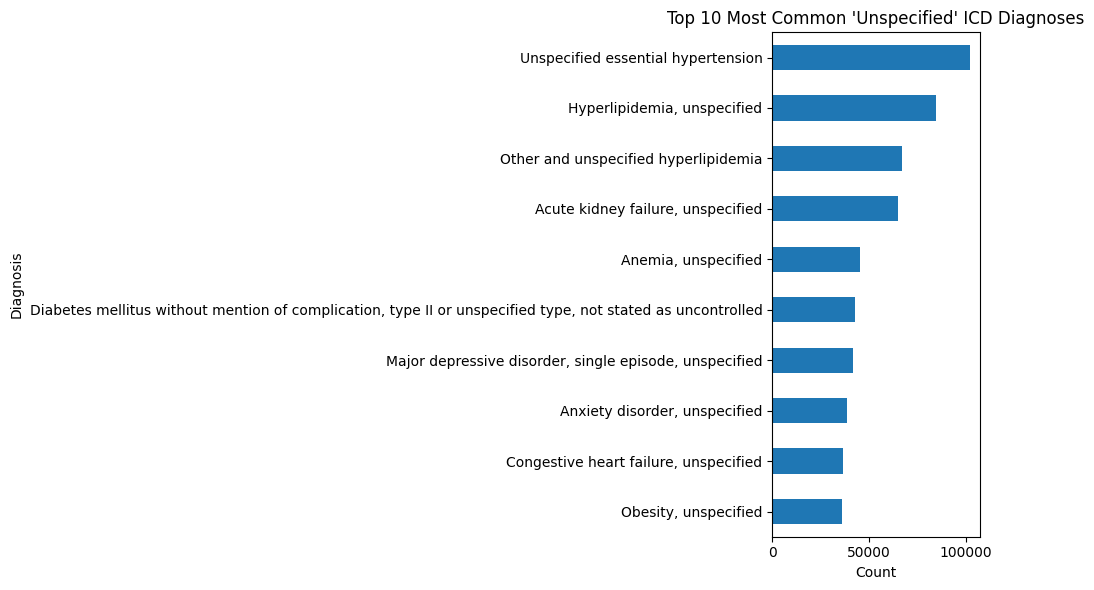

In [20]:
import matplotlib.pyplot as plt

# ---- Paths ----
diagnoses_path = "data/hosp/diagnoses_icd.csv.gz"
icd_lookup_path = "data/hosp/d_icd_diagnoses.csv.gz"

# ---- Load ----
diagnoses = pd.read_csv(diagnoses_path, low_memory=False)
icd_lookup = pd.read_csv(icd_lookup_path, low_memory=False)

# ---- Merge to add descriptions ----
diagnoses = diagnoses.merge(
    icd_lookup[["icd_code", "icd_version", "long_title"]],
    on=["icd_code", "icd_version"],
    how="left"
)

# ---- Find "unspecified" codes ----
unspecified = diagnoses[
    diagnoses["long_title"].str.contains("unspecified", case=False, na=False)
]

# ---- Stats ----
total = len(diagnoses)
unspec_count = len(unspecified)
unspec_pct = (unspec_count / total) * 100

print(f"Total diagnoses: {total:,}")
print(f"Unspecified diagnoses: {unspec_count:,}")
print(f"Percentage unspecified: {unspec_pct:.2f}%")

# ---- Top 10 unspecified codes ----
top_unspecified = unspecified["long_title"].value_counts().head(10)
print("\nTop 10 unspecified ICD codes:\n", top_unspecified)

# ---- Plot ----
plt.figure(figsize=(10, 6))
top_unspecified.plot(kind="barh")
plt.title("Top 10 Most Common 'Unspecified' ICD Diagnoses")
plt.xlabel("Count")
plt.ylabel("Diagnosis")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

Admissions by ICD version category:
version_category
Only ICD-9                291120
Only ICD-10               254367
Mixed (ICD-9 & ICD-10)        10
Name: count, dtype: int64

Percentage breakdown:
version_category
Only ICD-9                53.37
Only ICD-10               46.63
Mixed (ICD-9 & ICD-10)     0.00
Name: count, dtype: float64


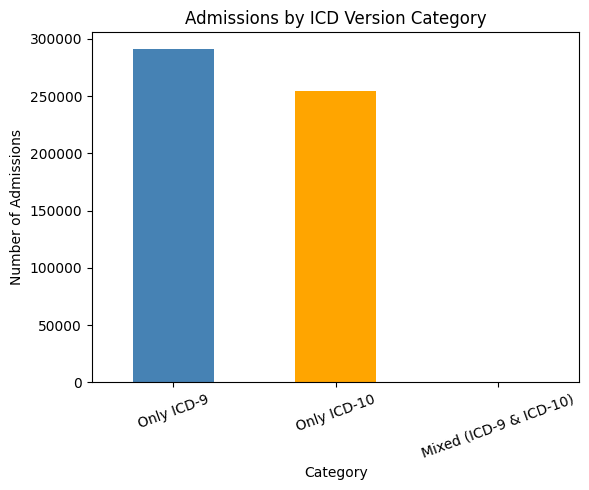

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load only the columns need to make this faster
diagnoses = pd.read_csv("data/hosp/diagnoses_icd.csv.gz", usecols=["hadm_id", "icd_version"], low_memory=False)

# Group by admission (hadm_id) and collect unique versions present
version_per_hadm = diagnoses.groupby("hadm_id")["icd_version"].unique().reset_index()

# Categorize each admission
def categorize(versions):
    versions = set(versions)
    if versions == {9}:
        return "Only ICD-9"
    elif versions == {10}:
        return "Only ICD-10"
    elif versions == {9, 10}:
        return "Mixed (ICD-9 & ICD-10)"
    else:
        return "Unknown"

version_per_hadm["version_category"] = version_per_hadm["icd_version"].apply(categorize)

# Count how many admissions fall into each category
category_counts = version_per_hadm["version_category"].value_counts()
print("Admissions by ICD version category:")
print(category_counts)
print("\nPercentage breakdown:")
print((category_counts / category_counts.sum() * 100).round(2))

# Visualize
plt.figure(figsize=(6, 5))
category_counts.plot(kind="bar", color=["steelblue", "orange", "violet"])
plt.title("Admissions by ICD Version Category")
plt.xlabel("Category")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
final.head(10)

,subject_id,hadm_id,text,icd_code,icd_version,long_title
0,10467237,20000019,\nName: ___ Unit No: ___\n \nA...,0389,9,Unspecified septicemia
1,16925328,20000024,\nName: ___ Unit No: ___\n \n...,D500,10,Iron deficiency anemia secondary to blood loss...
2,19430048,20000034,\nName: ___ Unit No: __...,K831,10,Obstruction of bile duct
3,18910522,20000041,\nName: ___ Unit No: ___\n \n...,71536,9,"Osteoarthrosis, localized, not specified wheth..."
4,11146739,20000057,\nName: ___ Unit No: ...,71907,9,"Effusion of joint, ankle and foot"
5,14046553,20000094,\nName: ___ Unit No: _...,I509,10,"Heart failure, unspecified"
6,13074106,20000102,\nName: ___ Unit No: ___\n...,64421,9,"Early onset of delivery, delivered, with or wi..."
7,14990224,20000147,\nName: ___ Unit No: __...,I213,10,ST elevation (STEMI) myocardial infarction of ...
8,12640657,20000235,\nName: ___ Unit No: ___\n ...,5722,9,Hepatic encephalopathy
9,13758099,20000239,\nName: ___ Unit No: ___\n \nA...,I120,10,Hypertensive chronic kidney disease with stage...


In [23]:
final.tail(10)

,subject_id,hadm_id,text,icd_code,icd_version,long_title
331594,10698563,29999501,\nName: ___ Unit No: ...,L03115,10,Cellulitis of right lower limb
331595,18440602,29999560,\nName: ___ Unit No: ___\...,9623,9,Poisoning by insulins and antidiabetic agents
331596,16741612,29999572,\nName: ___ Unit No: ___\...,99832,9,Disruption of external operation (surgical) wound
331597,14544496,29999596,\nName: ___ Unit No: ___\...,42833,9,Acute on chronic diastolic heart failure
331598,10355856,29999625,\nName: ___ Unit No: ___\n \n...,I614,10,Nontraumatic intracerebral hemorrhage in cereb...
331599,16289688,29999670,\nName: ___ Unit No: _...,41071,9,"Subendocardial infarction, initial episode of ..."
331600,10382924,29999723,\nName: ___ Unit No: __...,4019,9,Unspecified essential hypertension
331601,11326722,29999745,\nName: ___ Unit No: ___\n...,29680,9,"Bipolar disorder, unspecified"
331602,12133002,29999809,\nName: ___ Unit No: ___\...,41401,9,Coronary atherosclerosis of native coronary ar...
331603,16572164,29999828,\nName: ___ Unit No: ___\...,27801,9,Morbid obesity


In [28]:
import pandas as pd

# Where 'final' = merged dataset with columns: subject_id, hadm_id, text, icd_code, long_title, icd_version

# 1. Remove unspecified diagnoses
final = final[~final["long_title"].str.contains("unspecified", case=False, na=False)]

# 2. Keep only ICD-10
final = final[final["icd_version"] == 10]

# 3. Keep only the top 30 most frequent ICD-10 codes
top_codes = final["icd_code"].value_counts().head(30).index
final = final[final["icd_code"].isin(top_codes)]

# Optional: reset index for clarity
final = final.reset_index(drop=True)

# Print results
print("Filtered dataset shape:", final.shape)
print("Unique ICD codes left:", final['icd_code'].nunique())
print("\nTop ICD-10 codes in filtered dataset:")
print(final['icd_code'].value_counts().head(30))

# Save cleaned dataset
final.to_csv("data/processed/merged_single_label_cleaned_icd10_top30.csv.gz", index=False)
print("\nSaved → data/processed/merged_single_label_cleaned_icd10_top30.csv.gz")


Filtered dataset shape: (20676, 6)
Unique ICD codes left: 30

Top ICD-10 codes in filtered dataset:
icd_code
Z5111      2163
I214       1988
N390       1268
I110       1169
I2510       884
I25110      830
I350        824
T814XXA     792
J441        754
I2699       747
I671        683
R0789       602
R55         601
A4151       584
I5033       562
I5023       547
K7031       476
J690        474
K921        467
I480        417
G92         404
J9601       397
M1711       395
C7931       391
K831        387
E6601       379
S065X0A     379
L03116      377
M1712       370
I132        365
Name: count, dtype: int64

Saved → data/processed/merged_single_label_cleaned_icd10_top30.csv.gz


=== Top 30 Most Frequent ICD-10 Diagnoses ===
   icd_code                                         long_title  count  \
29    Z5111          Encounter for antineoplastic chemotherapy   2163   
6      I214    Non-ST elevation (NSTEMI) myocardial infarction   1988   
24     N390        Urinary tract infection, site not specified   1268   
4      I110      Hypertensive heart disease with heart failure   1169   
7     I2510  Atherosclerotic heart disease of native corona...    884   
8    I25110  Atherosclerotic heart disease of native corona...    830   
10     I350               Nonrheumatic aortic (valve) stenosis    824   
28  T814XXA  Infection following a procedure, initial encou...    792   
15     J441  Chronic obstructive pulmonary disease with (ac...    754   
9     I2699  Other pulmonary embolism without acute cor pul...    747   
14     I671                     Cerebral aneurysm, nonruptured    683   
25    R0789                                   Other chest pain    602   
26   

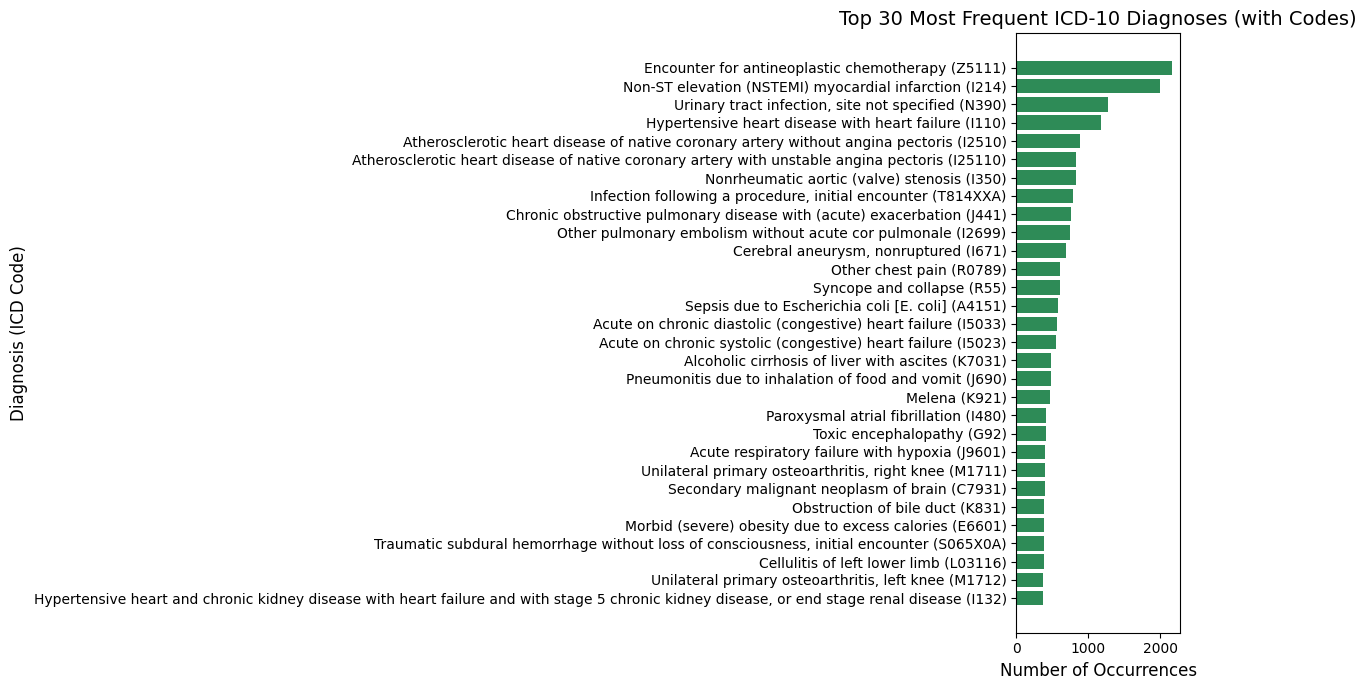


Saved full ICD-10 frequency table → data/processed/icd10_longtitle_frequency.csv


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load our final dataset ---
final = pd.read_csv("data/processed/merged_single_label_cleaned_icd10_top30.csv.gz")

# --- Group by ICD code and long title ---
icd_freq = (
    final.groupby(["icd_code", "long_title"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# --- Combine long_title and icd_code for better labeling ---
icd_freq["label"] = icd_freq.apply(lambda x: f"{x['long_title']} ({x['icd_code']})", axis=1)

# --- Display summary ---
print("=== Top 30 Most Frequent ICD-10 Diagnoses ===")
print(icd_freq.head(30))
print(f"\nTotal unique ICD-10 codes: {icd_freq['icd_code'].nunique()}")
print(f"Total rows in dataset: {len(final):,}")

# --- Plot the top 30 with combined label ---
top30 = icd_freq.head(30)

plt.figure(figsize=(12, 7))
plt.barh(
    y=top30["label"],
    width=top30["count"],
    color="seagreen",
)
plt.gca().invert_yaxis()  # highest count on top
plt.title("Top 30 Most Frequent ICD-10 Diagnoses (with Codes)", fontsize=14)
plt.xlabel("Number of Occurrences", fontsize=12)
plt.ylabel("Diagnosis (ICD Code)", fontsize=12)

# Improve readability
plt.tight_layout()
plt.show()

# --- Save frequency table to CSV ---
out_path = "data/processed/icd10_longtitle_frequency.csv"
icd_freq.to_csv(out_path, index=False)
print(f"\nSaved full ICD-10 frequency table → {out_path}")


In [26]:
# save as: make_plm_data.py (run with preferred interpreter)

import os
import pandas as pd
from sklearn.model_selection import train_test_split

SRC = r"data/processed/merged_single_label_cleaned_icd10_top30.csv.gz"  # cleaned file
OUT_DIR = r"PLM-ICD/data"  # write inside the PLM-ICD repo
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(SRC)
# Ensure one row per admission (should already be, but safe):
df = df.drop_duplicates(subset=["hadm_id"])

# Keep only what we need and rename to PLM-ICD format
df = df.rename(columns={"text":"TEXT", "icd_code":"LABELS"})
df = df[["TEXT","LABELS"]].copy()

# Train/dev/test split 80/10/10 (stratify by label to keep balance)
train_df, temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df["LABELS"])
dev_df, test_df = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp["LABELS"])

print("Train/dev/test sizes:", len(train_df), len(dev_df), len(test_df))
print("Num classes:", df["LABELS"].nunique())
print("Example labels:", df["LABELS"].value_counts().head())

train_df.to_csv(os.path.join(OUT_DIR, "train_full.csv"), index=False)
dev_df.to_csv(os.path.join(OUT_DIR, "dev_full.csv"), index=False)
test_df.to_csv(os.path.join(OUT_DIR, "test_full.csv"), index=False)

# create a label vocabulary file for clarity
codes = sorted(df["LABELS"].unique())
with open(os.path.join(OUT_DIR, "label_vocab.txt"), "w", encoding="utf-8") as f:
    for c in codes:
        f.write(str(c).strip() + "\n")
print("Wrote label_vocab.txt with", len(codes), "codes.")


Train/dev/test sizes: 16540 2068 2068
Num classes: 30
Example labels: LABELS
Z5111    2163
I214     1988
N390     1268
I110     1169
I2510     884
Name: count, dtype: int64
Wrote label_vocab.txt with 30 codes.


In [29]:
import pandas as pd, os

for name in ["train_full.csv", "dev_full.csv", "test_full.csv"]:
    p = os.path.abspath(os.path.join("PLM-ICD", "data", name))
    df = pd.read_csv(p)
    print(name, "→ path:", p, "| rows:", len(df), "| cols:", list(df.columns))


train_full.csv → path: C:\Users\namirahimtieazshaik\PyCharmMiscProject\PLM-ICD\data\train_full.csv | rows: 16540 | cols: ['TEXT', 'LABELS']
dev_full.csv → path: C:\Users\namirahimtieazshaik\PyCharmMiscProject\PLM-ICD\data\dev_full.csv | rows: 2068 | cols: ['TEXT', 'LABELS']
test_full.csv → path: C:\Users\namirahimtieazshaik\PyCharmMiscProject\PLM-ICD\data\test_full.csv | rows: 2068 | cols: ['TEXT', 'LABELS']


In [30]:
# Check number of classes in each split and that totals line up
import pandas as pd, os
base = r"PLM-ICD\data"
for f in ["train_full.csv", "dev_full.csv", "test_full.csv"]:
    df = pd.read_csv(os.path.join(base, f))
    print(f, len(df), "rows | classes:", df["LABELS"].nunique())
print("label_vocab.txt lines:",
      sum(1 for _ in open(os.path.join(base, "label_vocab.txt"), encoding="utf-8")))


train_full.csv 16540 rows | classes: 30
dev_full.csv 2068 rows | classes: 30
test_full.csv 2068 rows | classes: 30
label_vocab.txt lines: 30


Single-label ICD codes: 5252
Multi-label ICD codes : 14188


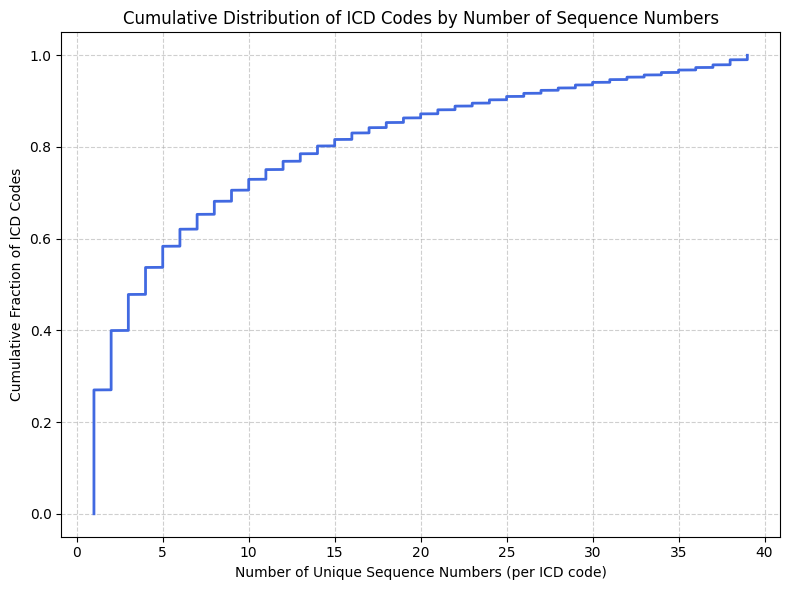

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load diagnoses table (adjust the path if needed) ---
diagnoses = pd.read_csv("data/hosp/diagnoses_icd.csv.gz", low_memory=False)

# ✅ Keep only ICD-10 codes
diagnoses = diagnoses[diagnoses["icd_version"] == 10]

# --- 2. Compute how many sequence numbers (diagnoses per admission) each ICD code appears with ---
icd_seq_counts = (
    diagnoses.groupby("icd_code")["seq_num"]
    .nunique()  # count unique seq_num values per icd_code
    .reset_index(name="unique_seq_nums")
)

# --- 3. Determine single-label vs. multi-label codes ---
icd_seq_counts["label_type"] = np.where(icd_seq_counts["unique_seq_nums"] == 1, "single", "multi")

print("Single-label ICD codes:", (icd_seq_counts["label_type"] == "single").sum())
print("Multi-label ICD codes :", (icd_seq_counts["label_type"] == "multi").sum())

# --- 4. Build cumulative distribution ---
sorted_counts = np.sort(icd_seq_counts["unique_seq_nums"].values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

# --- 5. Plot CDF ---
plt.figure(figsize=(8, 6))
plt.plot(sorted_counts, cdf, lw=2, color="royalblue")
plt.title("Cumulative Distribution of ICD Codes by Number of Sequence Numbers")
plt.xlabel("Number of Unique Sequence Numbers (per ICD code)")
plt.ylabel("Cumulative Fraction of ICD Codes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



C:\Users\namirahimtieazshaik\AppData\Local\Temp\ipykernel_34764\3407398426.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0.03, 1, 0.94))


Saved full frequency table → data/processed/icd10_longtitle_frequency.csv


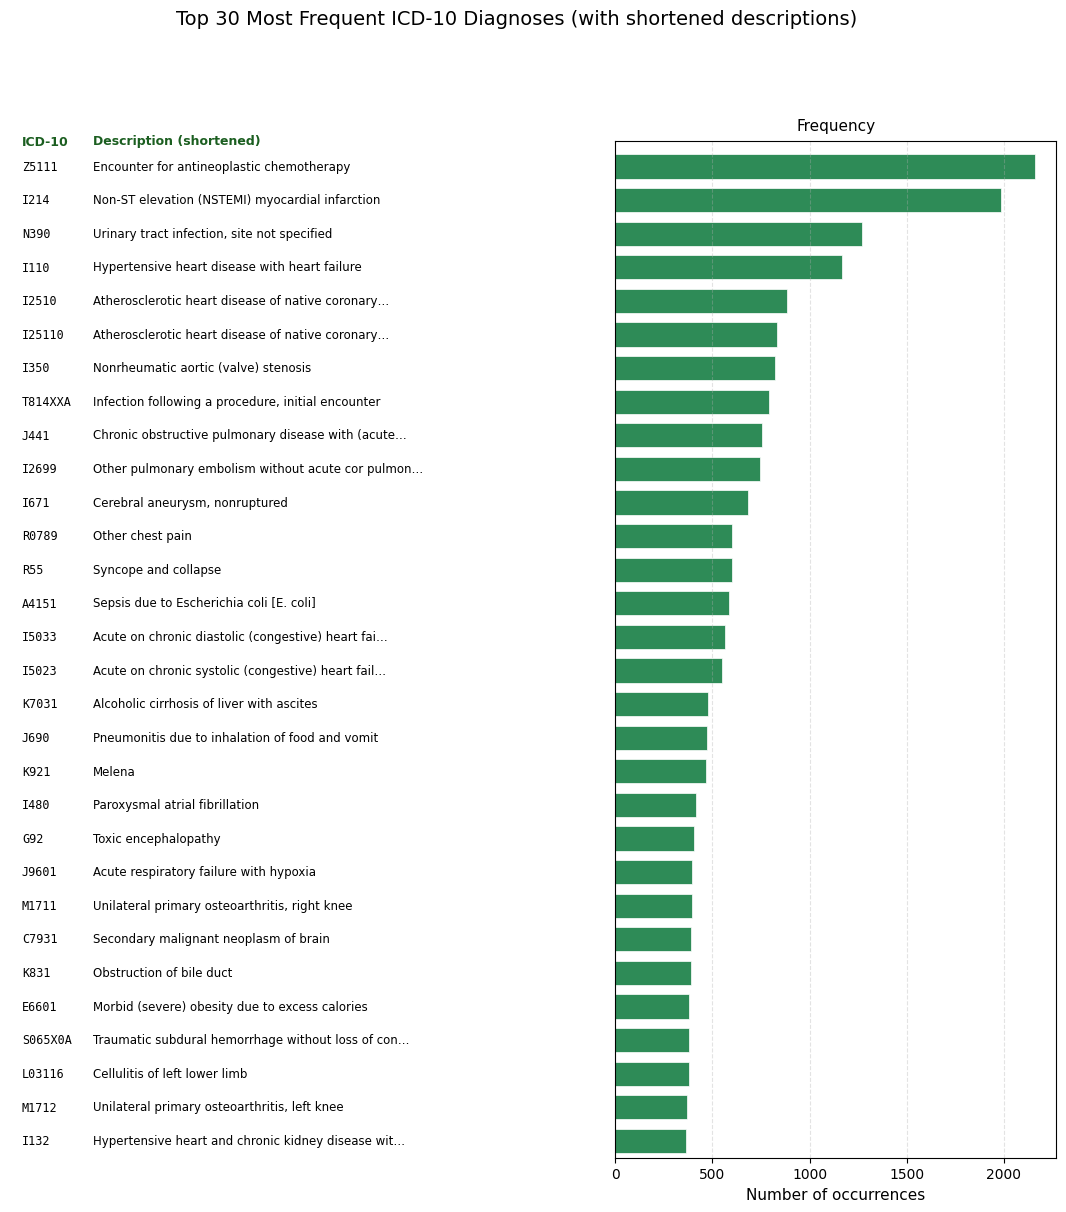

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load & aggregate (same logic as earlier cell) ---
final = pd.read_csv("data/processed/merged_single_label_cleaned_icd10_top30.csv.gz")
icd_freq = (
    final.groupby(["icd_code", "long_title"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
top30 = icd_freq.head(30).copy()


def shorten_label(s: str, max_len: int = 50) -> str:
    """Uniform visual width: one line, ellipsis if needed (appealing bar-chart labels)."""
    s = " ".join(str(s).split())
    if len(s) <= max_len:
        return s
    return s[: max_len - 1].rstrip() + "…"


top30["short_title"] = top30["long_title"].apply(lambda x: shorten_label(x, 50))

# --- Figure: shared y → each text row lines up with its bar (row-by-row alignment) ---
n = len(top30)
y = np.arange(n, dtype=float)
counts = top30["count"].values

fig, (ax_tbl, ax_bar) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(13.5, max(8.0, 0.38 * n + 1.8)),
    gridspec_kw={"width_ratios": [1.35, 1.0], "wspace": 0.02},
)

ax_bar.barh(y, counts, color="seagreen", height=0.72, edgecolor="white", linewidth=0.5)
ax_bar.invert_yaxis()
ax_bar.set_xlabel("Number of occurrences", fontsize=11)
ax_bar.grid(axis="x", linestyle="--", alpha=0.35)
ax_bar.set_yticks([])

# Reserve space above the top bar for column headers (same y scale as bars)
hdr_y = -0.75
ax_bar.set_ylim(n - 0.5, hdr_y)

ax_tbl.set_xlim(0, 1)
ax_tbl.axis("off")
# Column headers (aligned with table area)
ax_tbl.text(
    0.02,
    hdr_y,
    "ICD-10",
    ha="left",
    va="center",
    fontsize=9,
    fontweight="bold",
    color="#1b5e20",
)
ax_tbl.text(
    0.14,
    hdr_y,
    "Description (shortened)",
    ha="left",
    va="center",
    fontsize=9,
    fontweight="bold",
    color="#1b5e20",
)
for j, (_, row) in enumerate(top30.iterrows()):
    ax_tbl.text(
        0.02,
        float(j),
        str(row["icd_code"]),
        ha="left",
        va="center",
        fontsize=8.5,
        family="monospace",
    )
    ax_tbl.text(
        0.14,
        float(j),
        str(row["short_title"]),
        ha="left",
        va="center",
        fontsize=8.5,
    )

ax_bar.set_title("Frequency", fontsize=11, pad=8)
fig.suptitle(
    "Top 30 Most Frequent ICD-10 Diagnoses (with shortened descriptions)",
    fontsize=14,
)
plt.tight_layout(rect=(0, 0.03, 1, 0.94))

out_csv = "data/processed/icd10_longtitle_frequency.csv"
icd_freq.to_csv(out_csv, index=False)
print(f"Saved full frequency table → {out_csv}")
plt.show()
